# LIBERO-90 Task 0 Dataloader Smoke Test

This notebook creates a dataloader for `antoniomari/libero_90` filtered to task `0`, then inspects:

- one training batch (`obs`, `actions`)
- one transformed dataset sample (`dataset[0]`)
- image-like tensors rendered for visual sanity checks

In [1]:
from pathlib import Path
import os
import sys
from typing import Any

import numpy as np
import matplotlib.pyplot as plt

# repo root: /cluster/home/anmari/meta_vlas
repo_root = Path("/cluster/home/anmari/meta_vlas")
os.chdir(repo_root)
print("cwd:", Path.cwd())

PROJECT_ROOT = Path('/cluster/home/anmari/meta_vlas')
for p in [PROJECT_ROOT, PROJECT_ROOT / 'src', PROJECT_ROOT / 'meta_libero']:
    p = str(p)
    if p not in sys.path:
        sys.path.insert(0, p)

os.environ.setdefault('HF_HOME', str(Path.home() / '.cache' / 'huggingface'))
os.environ.setdefault('HF_LEROBOT_HOME', str(Path(os.environ['HF_HOME']) / 'lerobot'))

import openpi.training.config as _config
import openpi.training.data_loader as _data_loader
from meta_libero.src.dataset import override_create_torch_dataset

print('Setup done.')
print('HF_LEROBOT_HOME =', os.environ['HF_LEROBOT_HOME'])

cwd: /cluster/home/anmari/meta_vlas


2026-03-11 22:12:31.846835: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-11 22:12:31.846890: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-11 22:12:31.848010: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-11 22:12:32.899467: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Setup done.
HF_LEROBOT_HOME = /cluster/home/anmari/.cache/huggingface/lerobot


In [2]:
repo_id = 'antoniomari/libero_90'
task_id = 0

train_config = _config.get_config('pi05_libero')

with override_create_torch_dataset(repo_id=repo_id):
    dataloader = _data_loader.create_data_loader(
        train_config,
        sharding=None,
        shuffle=False,
    )

# Keep a handle to the underlying dataset object used by the dataloader.
dataset = dataloader._data_loader._data_loader.dataset

print('Repo ID:', repo_id)
print('Task ID:', task_id)
print('Dataloader type:', type(dataloader))
print('Dataset type:', type(dataset))
print('Dataset length:', len(dataset))

Resolving data files:   0%|          | 0/3917 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/109 [00:00<?, ?it/s]

Repo ID: antoniomari/libero_90
Task ID: 0
Dataloader type: <class 'openpi.training.data_loader.DataLoaderImpl'>
Dataset type: <class 'openpi.training.data_loader.TransformedDataset'>
Dataset length: 567494


/cluster/home/anmari/meta_vlas/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [3]:
sample = dataset[0]
print('Sample type:', type(sample))

# Print top-level keys and shape-like info.
if isinstance(sample, dict):
    print('Top-level keys:', list(sample.keys()))
    for k, v in sample.items():
        if hasattr(v, 'shape'):
            print(f'  {k}: shape={tuple(v.shape)}, dtype={getattr(v, "dtype", type(v))}')
        else:
            print(f'  {k}: type={type(v)}')
else:
    print('Sample is not dict; repr:')
    print(sample)

Sample type: <class 'dict'>
Top-level keys: ['state', 'image', 'image_mask', 'actions', 'task_index', 'tokenized_prompt', 'tokenized_prompt_mask']
  state: shape=(32,), dtype=float64
  image: type=<class 'dict'>
  image_mask: type=<class 'dict'>
  actions: shape=(10, 32), dtype=float64
  task_index: shape=(), dtype=torch.int64
  tokenized_prompt: shape=(200,), dtype=int64
  tokenized_prompt_mask: shape=(200,), dtype=bool


[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /cluster/home/anmari/meta_vlas/.venv/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


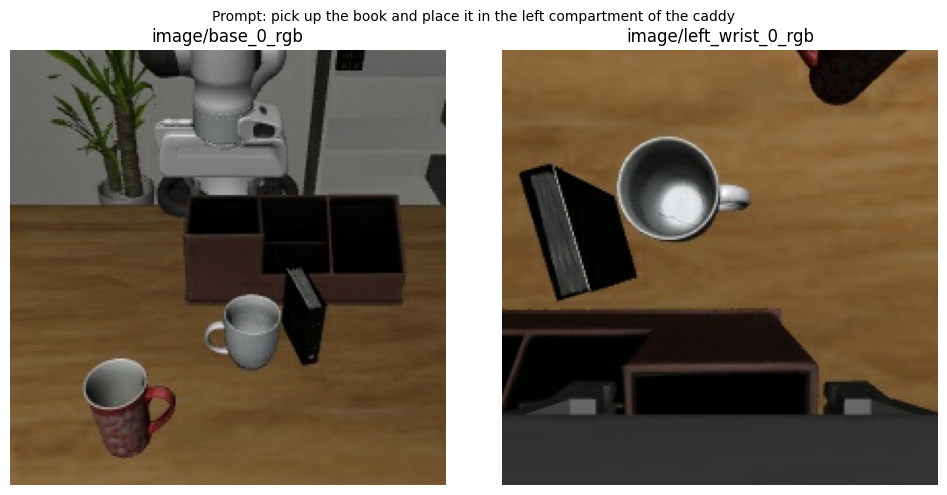

In [4]:
# Visualize image-like arrays from sample (supports nested dicts, HWC or CHW).
# Ignore right_wrist view (masked out / all zeros) and show prompt in title.

def to_hwc_uint8(arr):
    arr = np.asarray(arr)
    if arr.ndim == 4:  # take first item if accidentally batched
        arr = arr[0]
    if arr.ndim == 3 and arr.shape[0] == 3:  # CHW -> HWC
        arr = np.transpose(arr, (1, 2, 0))
    if arr.ndim != 3 or arr.shape[-1] != 3:
        return None
    if np.issubdtype(arr.dtype, np.floating):
        lo, hi = float(arr.min()), float(arr.max())
        if lo >= -1.1 and hi <= 1.1:
            arr = (arr + 1.0) / 2.0
        arr = np.clip(arr, 0.0, 1.0)
        arr = (arr * 255).astype(np.uint8)
    else:
        arr = arr.astype(np.uint8)
    return arr


def collect_images(x, prefix=''):
    out = []
    if isinstance(x, dict):
        for k, v in x.items():
            key = f'{prefix}/{k}' if prefix else k
            # right wrist image is masked out in this setup
            if 'right_wrist' in key:
                continue
            out.extend(collect_images(v, key))
        return out
    img = to_hwc_uint8(x)
    if img is not None:
        out.append((prefix, img))
    return out


def get_prompt_text(x):
    if not isinstance(x, dict):
        return '<prompt unavailable>'

    # 1) Prefer raw prompt if present.
    p = x.get('prompt', None)
    if p is not None:
        if isinstance(p, str):
            return p
        try:
            p = np.asarray(p)
            if p.ndim == 0:
                return str(p.item())
            if p.ndim >= 1 and p.shape[0] > 0:
                return str(p[0])
        except Exception:
            pass

    # 2) Fallback: decode tokenized prompt.
    tok = x.get('tokenized_prompt', None)
    tok_mask = x.get('tokenized_prompt_mask', None)
    if tok is not None:
        try:
            from meta_libero.rendering import decode_tokenized_prompt

            tok = np.asarray(tok)
            tok_mask = np.asarray(tok_mask) if tok_mask is not None else None

            # If batched, use first sample.
            if tok.ndim >= 2:
                tok = tok[0]
                if tok_mask is not None and tok_mask.ndim >= 2:
                    tok_mask = tok_mask[0]

            decoded = decode_tokenized_prompt(
                tokenized_prompt=tok,
                tokenized_prompt_mask=tok_mask,
                max_token_len=200,
                fallback_text='<prompt unavailable>',
            )
            return decoded
        except Exception:
            pass

    return '<prompt unavailable>'

candidates = collect_images(sample) if isinstance(sample, dict) else []
prompt_text = get_prompt_text(sample)

if not candidates:
    print('No image-like tensors found in sample.')
else:
    n = len(candidates)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (name, img) in zip(axes, candidates):
        ax.imshow(img)
        ax.set_title(name)
        ax.axis('off')
    fig.suptitle(f'Prompt: {prompt_text}', fontsize=10)
    plt.tight_layout()
    plt.show()

In [5]:
def _sample_to_img(sample, key="base_0_rgb"):
    """Extract image array from dataset sample for display."""
    x = None
    if isinstance(sample, dict):
        if "image" in sample and isinstance(sample["image"], dict):
            x = sample["image"].get(key)
        elif "observation" in sample and isinstance(sample["observation"], dict):
            obs = sample["observation"]
            if "images" in obs and isinstance(obs["images"], dict):
                x = obs["images"].get(key)
    if x is None:
        return None
    x = np.asarray(x)
    if x.ndim == 3 and x.shape[0] == 3:  # CHW -> HWC
        x = np.transpose(x, (1, 2, 0))
    if np.issubdtype(x.dtype, np.floating):
        lo, hi = float(x.min()), float(x.max())
        if lo >= -1.1 and hi <= 1.1:
            x = (x + 1.0) / 2.0
        x = np.clip(x, 0.0, 1.0)
    else:
        x = x.astype(np.float32) / 255.0
    return x


def show_episode_progression_rows(dataset, episode_indices, n=4, episodes=None, max_episodes=12):
    """
    Plot n equidistant frames per episode (beginning, middle, end).
    Each row = one episode; each column = one frame along the episode.
    episodes: optional list of indices into episode list (e.g. [0,1,2] for first 3 episodes).
    """
    ep_ids = list(episode_indices.keys())
    if episodes is not None:
        ep_ids = [ep_ids[i] for i in episodes if 0 <= i < len(ep_ids)]
    ep_ids = ep_ids[:max_episodes]

    if not ep_ids:
        print("No episodes to show.")
        return

    n_eps = len(ep_ids)
    fig, axes = plt.subplots(n_eps, n, figsize=(3 * n, 3 * n_eps), squeeze=False)

    for row, ep_id in enumerate(ep_ids):
        indices = episode_indices[ep_id]
        L = len(indices)
        if L == 0:
            continue
        # Equidistant frame indices: 0, ..., L-1 for n frames
        if n == 1:
            pick = [0]
        else:
            pick = [int(round(i * (L - 1) / (n - 1))) for i in range(n)]
            pick = [min(p, L - 1) for p in pick]

        for col, idx_in_ep in enumerate(pick):
            logical_idx = indices[idx_in_ep]
            sample = dataset[logical_idx]
            img = _sample_to_img(sample)
            ax = axes[row, col]
            if img is not None:
                ax.imshow(img)
            ax.set_title(f"ep {ep_id} t={idx_in_ep}/{L-1}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

In [6]:
# Decode tokenized prompts (query + fetched neighbors) to human-readable text.

from meta_libero.rendering import decode_tokenized_prompt

def decode_prompt_from_obs(observation, idx=0, max_token_len=200):
    tokens = None
    mask = None

    if hasattr(observation, 'tokenized_prompt'):
        tokens = observation.tokenized_prompt
    if hasattr(observation, 'tokenized_prompt_mask'):
        mask = observation.tokenized_prompt_mask

    if tokens is None:
        return '<no tokenized prompt>'

    tokens_np = np.asarray(tokens)
    mask_np = np.asarray(mask) if mask is not None else None

    if tokens_np.ndim == 2:
        tokens_np = tokens_np[idx]
        if mask_np is not None and mask_np.ndim == 2:
            mask_np = mask_np[idx]

    return decode_tokenized_prompt(
        tokenized_prompt=tokens_np,
        tokenized_prompt_mask=mask_np,
        max_token_len=max_token_len,
        fallback_text='<decode failed>',
    )

query_prompt_text = decode_prompt_from_obs(query_observation, idx=0)
print('Query decoded prompt:')
print(query_prompt_text)

print('\nTop-k neighbor decoded prompts:')
n_neighbors = int(np.asarray(nn_obs.tokenized_prompt).shape[0]) if hasattr(nn_obs, 'tokenized_prompt') else 0
for i in range(min(k, n_neighbors)):
    neighbor_prompt = decode_prompt_from_obs(nn_obs, idx=i)
    print(f'  {i:02d} | score={float(distances[i]):.6f} | idx={int(indices[i])} | {neighbor_prompt}')

NameError: name 'query_observation' is not defined

In [9]:
from collections import defaultdict
import numpy as np

def get_episode_indices_by_task(dataset, task_index=None):
    """
    Return {episode_id: [logical dataset indices]}.
    Works even when transformed samples don't expose episode keys.
    """
    # Unwrap to find filtered indices + base dataset with hf_dataset
    cur = dataset
    logical_to_physical = None

    while True:
        if hasattr(cur, "indices"):  # FilteredDataset
            logical_to_physical = list(cur.indices)
        if hasattr(cur, "hf_dataset"):
            base = cur
            break
        if hasattr(cur, "_dataset"):
            cur = cur._dataset
        elif hasattr(cur, "dataset"):
            cur = cur.dataset
        else:
            raise RuntimeError("Could not find underlying dataset with hf_dataset")

    hf = base.hf_dataset
    col_names = set(hf.column_names)

    # Episode column candidates
    ep_col = next(
        (c for c in ("episode_index", "episode_id", "episode", "episode_idx") if c in col_names),
        None,
    )
    if ep_col is None:
        raise KeyError(f"No episode column found in hf_dataset. Columns: {sorted(col_names)}")

    task_col = "task_index" if "task_index" in col_names else None

    ep_values = np.asarray(hf[ep_col])
    task_values = np.asarray(hf[task_col]) if task_col is not None else None

    n = len(dataset)
    if logical_to_physical is None:
        logical_to_physical = list(range(n))

    episode_to_indices = defaultdict(list)
    for logical_idx in range(n):
        physical_idx = int(logical_to_physical[logical_idx])

        if task_index is not None and task_values is not None:
            if int(task_values[physical_idx]) != int(task_index):
                continue

        ep = int(ep_values[physical_idx])
        episode_to_indices[ep].append(logical_idx)

    for ep in episode_to_indices:
        episode_to_indices[ep].sort()
    return dict(sorted(episode_to_indices.items()))

num episodes: 40
first 10 episode ids: [4, 238, 419, 513, 547, 548, 583, 584, 845, 855]


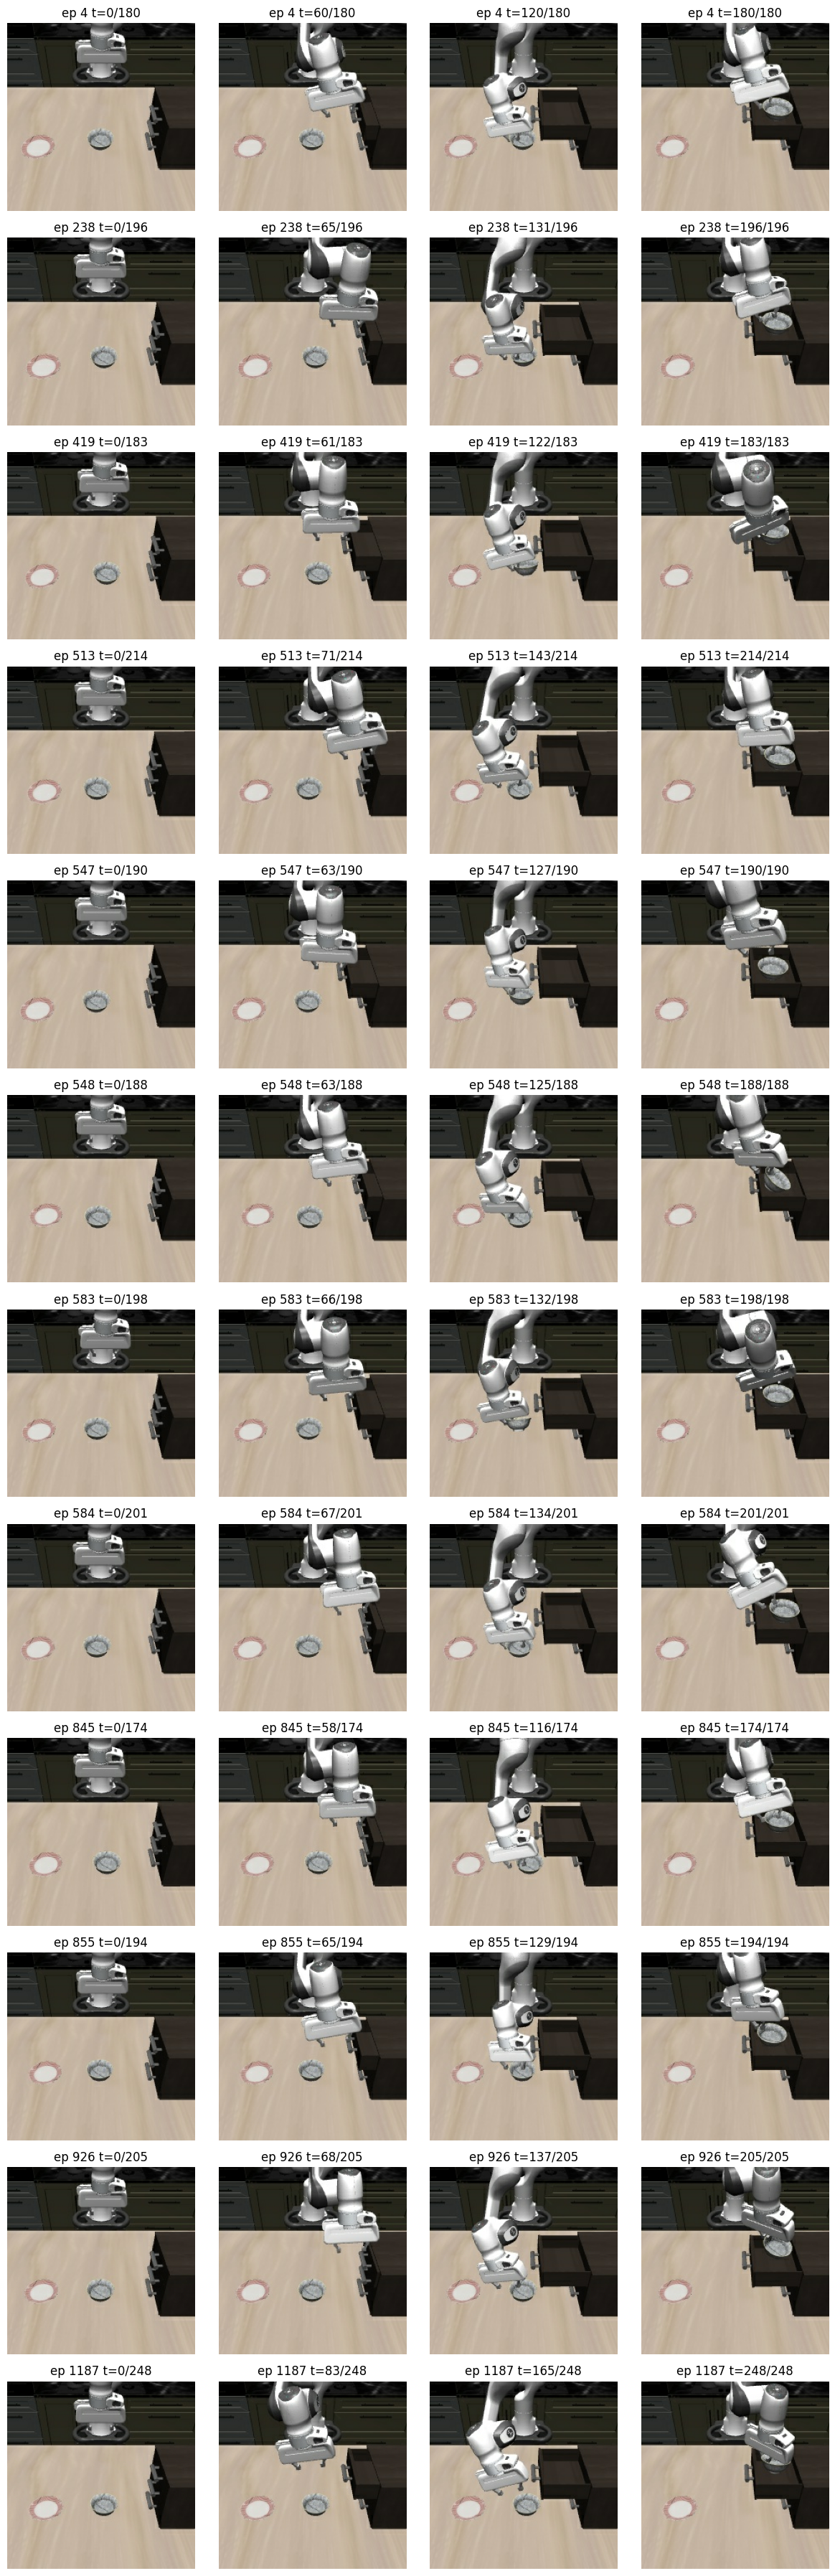

In [18]:
# Usage example
# Assumes `dataset`, `get_episode_indices_by_task`, and `show_episode_progression_rows` are already defined.
from meta_libero.src.dataset import LIBERO_90_TASK_IDS_MAPPING


# For task 0 in libero_90 filtered dataset, task_index is typically 55.
task_id = LIBERO_90_TASK_IDS_MAPPING[8]
task0_episode_indices = get_episode_indices_by_task(dataset, task_index=task_id)
print(f"num episodes: {len(task0_episode_indices)}")
print("first 10 episode ids:", list(task0_episode_indices.keys())[:10])

# Visualize all episodes (N snapshots per episode, progressively across time)
show_episode_progression_rows(dataset, task0_episode_indices, n=4)

# Or visualize only selected episodes
# show_episode_progression_rows(dataset, task0_episode_indices, n=6, episodes=[0, 1, 2])
